# Hopfield 1982：按论文顺序复现全部计算实验

这份 notebook 把论文中的计算研究组织成一条固定但允许跳步的流水线：

**a 记忆 → b 权重 → c 初态 → d 动力学 → e 测量 → f 展示**

函数名中的字母表示组件类别，数字表示该类别中的选择。例如：

```text
a1 → b1 → c3 → d1 → e1 → f1
随机记忆 → Hebb 权重 → 扰动初态 → 异步更新 → 汉明距离 → 曲线
```

本文原始状态编码为 $\{0,1\}$ ；代码统一使用等价的 $\{-1,+1\}$ 编码。这样阈值为零时，更新规则是 $\operatorname{sign}(T V)$。

论文：J. J. Hopfield, *Neural networks and physical systems with emergent collective computational abilities*, PNAS 79, 2554–2558 (1982). [DOI](https://doi.org/10.1073/pnas.79.8.2554)


## 0. 论文实验地图

论文没有为每个实验单列小标题。下面各项都位于大标题 **Studies of the collective behaviors of the model**（论文 pp. 2556–2558）之下。

| 顺序 | 类型 | 论文问题 | 组件配方 |
|---:|---|---|---|
| 1 | 论文实验 | 非对称随机连接会收敛、循环还是游走？ | `b2 → c2 → d1 → e3 → f2` |
| 2 | 论文实验 | 随存储数增加，召回何时崩溃？ | `a1 → b1 → c1 → d1 → e1 → f1` |
| 3 | 论文实验 | 任意随机初态最终落到哪里？ | `a1 → b1 → c2 → d1 → e2 → f2` |
| 4 | 论文实验 | 吸引盆和纠错半径有多大？ | `a1 → b1 → c3 → d1 → e2 → f1` |
| 5 | 论文实验 | 权重只保留符号会损失多少容量？ | `a1 → b1+b3 → c1 → d1 → e1 → f2` |
| 6 | 机制扩展 | 有限整数权重能否自然遗忘？ | `a1 → b5 → c1 → d1 → e1 → f1` |
| 7 | 论文实验 | 每对神经元只留一个方向会怎样？ | `a1 → b1+b4 → c1 → d1 → e1 → f2` |
| 8 | 论文实验 | 太相似的记忆何时融合？ | `a2 → b1 → c1 → d1 → e1/e2 → f1` |
| 9 | 机制扩展 | 阈值能否产生“不熟悉”状态？ | `a1 → b1 → c1/c4 → d1 → e2 → f1` |
| 10 | 论文实验 | 严重过载后还能识别熟悉度吗？ | `a1 → b1 → c1/c4 → e4 → f2` |
| 11 | 机制扩展 | 相关结构能否帮助部分信息补全？ | `a3 → b1 → c3 → d1 → e1 → f2` |
| 12 | 论文实验 | 非对称项能否编码时间序列？ | `a1 → b1+b6 → c1 → d1 → e5 → f2` |

严格按“给出参数、运行模型并报告观察结果”计为 9 组论文实验；另外 3 组是论文提出但没有完整统计表的机制扩展。


## 1. 公共实验组件

这一节只定义公共机制。首次打开或修改组件后，请执行 **Runtime → Restart session and run all**，避免 notebook 的旧状态污染结果。

### 1.1 环境、结果对象与随机数


In [19]:
from dataclasses import dataclass
from math import erfc, exp, sqrt
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")


@dataclass
class DynamicsResult:
    final_state: np.ndarray
    sweeps: int
    status: str
    flips_per_sweep: tuple[int, ...]
    state_history: Optional[list[np.ndarray]] = None
    energy_history: Optional[list[float]] = None


SEED = 0


### 1.2 a：记忆生成

- `a1`：相互独立的随机记忆。
- `a2`：构造一对具有指定汉明距离的相似记忆。
- `a3`：围绕共同原型生成相关记忆。


In [20]:
def a1_make_random_memories(
    n: int,
    N: int,
    rng: np.random.Generator,
) -> np.ndarray:
    return rng.choice(np.array([-1, 1], dtype=np.int8), size=(n, N))


def a2_make_close_memories(
    n: int,
    N: int,
    distance: int,
    rng: np.random.Generator,
) -> np.ndarray:
    if n < 2:
        raise ValueError("n 至少为 2")
    memories = a1_make_random_memories(n=n, N=N, rng=rng)
    memories[-1] = memories[0].copy()
    flip_indices = rng.choice(N, size=distance, replace=False)
    memories[-1, flip_indices] *= -1
    return memories


def a3_make_correlated_memories(
    n: int,
    N: int,
    flip_probability: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    prototype = a1_make_random_memories(n=1, N=N, rng=rng)[0]
    memories = np.repeat(prototype[None, :], n, axis=0)
    flip_mask = rng.random((n, N)) < flip_probability
    memories[flip_mask] *= -1
    return memories, prototype


### 1.3 b：权重构造与变换

`b1` 是标准 Hebb 权重；`b3`–`b6` 都是显式变换，因此实验代码能直接显示在标准权重上增加了什么。


In [21]:
def b1_hebb_weights(memories: np.ndarray) -> np.ndarray:
    weights = memories.astype(float).T @ memories.astype(float)
    np.fill_diagonal(weights, 0.0)
    return weights


def b2_random_asymmetric_weights(
    N: int,
    rng: np.random.Generator,
) -> np.ndarray:
    weights = rng.uniform(-1.0, 1.0, size=(N, N))
    np.fill_diagonal(weights, 0.0)
    return weights


def b3_clip_weights(weights: np.ndarray) -> np.ndarray:
    clipped = np.sign(weights)
    np.fill_diagonal(clipped, 0.0)
    return clipped


def b4_keep_one_direction(
    weights: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    one_way = np.zeros_like(weights)
    N = weights.shape[0]
    for i in range(N):
        for j in range(i + 1, N):
            if rng.random() < 0.5:
                one_way[i, j] = weights[i, j]
            else:
                one_way[j, i] = weights[j, i]
    return one_way


def b5_add_memory_with_saturation(
    weights: np.ndarray,
    memory: np.ndarray,
    limit: int = 3,
) -> np.ndarray:
    updated = weights + np.outer(memory, memory)
    np.fill_diagonal(updated, 0)
    return np.clip(updated, -limit, limit)


def b6_add_sequence_terms(
    weights: np.ndarray,
    memories: np.ndarray,
    strength: float,
) -> np.ndarray:
    sequenced = weights.astype(float).copy()
    for current, following in zip(memories[:-1], memories[1:]):
        sequenced += strength * np.outer(following, current)
    np.fill_diagonal(sequenced, 0.0)
    return sequenced


### 1.4 c：初始状态


In [22]:
def c1_start_from_memory(
    memories: np.ndarray,
    index: int,
) -> np.ndarray:
    return memories[index].copy()


def c2_random_state(
    N: int,
    rng: np.random.Generator,
) -> np.ndarray:
    return rng.choice(np.array([-1, 1], dtype=np.int8), size=N)


def c3_perturb_memory(
    memory: np.ndarray,
    n_flips: int,
    rng: np.random.Generator,
) -> np.ndarray:
    state = memory.copy()
    indices = rng.choice(memory.size, size=n_flips, replace=False)
    state[indices] *= -1
    return state


def c4_unfamiliar_state(
    N: int,
    rng: np.random.Generator,
) -> np.ndarray:
    return c2_random_state(N=N, rng=rng)


### 1.5 d：动力学

`d1_run_async` 默认只返回终态和轻量摘要。只有明确设置 `record_states=True` 或 `record_energy=True` 时才保存过程数据。

注意：能量单调性只适用于对称权重。非对称实验不得把 `record_energy=True` 当作收敛证明。


In [23]:
def _energy(weights: np.ndarray, state: np.ndarray) -> float:
    return float(-0.5 * state @ weights @ state)


def _threshold_at(threshold: float | np.ndarray, i: int) -> float:
    return float(threshold if np.isscalar(threshold) else threshold[i])


def d1_run_async(
    weights: np.ndarray,
    initial_state: np.ndarray,
    rng: np.random.Generator,
    max_sweeps: int = 50,
    threshold: float | np.ndarray = 0.0,
    record_states: bool = False,
    record_energy: bool = False,
) -> DynamicsResult:
    state = initial_state.copy()
    state_history = [state.copy()] if record_states else None
    energy_history = [_energy(weights, state)] if record_energy else None
    flips_per_sweep: list[int] = []

    for sweep in range(1, max_sweeps + 1):
        flips = 0
        for i in rng.permutation(state.size):
            local_field = weights[i] @ state - _threshold_at(threshold, i)
            new_value = 1 if local_field > 0 else -1 if local_field < 0 else state[i]
            if new_value != state[i]:
                state[i] = new_value
                flips += 1
                if record_states:
                    state_history.append(state.copy())
                if record_energy:
                    energy_history.append(_energy(weights, state))

        flips_per_sweep.append(flips)
        if flips == 0:
            return DynamicsResult(
                final_state=state,
                sweeps=sweep,
                status="fixed",
                flips_per_sweep=tuple(flips_per_sweep),
                state_history=state_history,
                energy_history=energy_history,
            )

    return DynamicsResult(
        final_state=state,
        sweeps=max_sweeps,
        status="max_sweeps",
        flips_per_sweep=tuple(flips_per_sweep),
        state_history=state_history,
        energy_history=energy_history,
    )


def d2_run_sync(
    weights: np.ndarray,
    initial_state: np.ndarray,
    max_steps: int = 100,
    record_states: bool = False,
) -> DynamicsResult:
    state = initial_state.copy()
    previous = None
    state_history = [state.copy()] if record_states else None
    flips_per_step: list[int] = []

    for step in range(1, max_steps + 1):
        local_fields = weights @ state
        new_state = state.copy()
        new_state[local_fields > 0] = 1
        new_state[local_fields < 0] = -1
        flips_per_step.append(int(np.count_nonzero(new_state != state)))
        if record_states:
            state_history.append(new_state.copy())

        if np.array_equal(new_state, state):
            return DynamicsResult(
                new_state, step, "fixed", tuple(flips_per_step), state_history
            )
        if previous is not None and np.array_equal(new_state, previous):
            return DynamicsResult(
                new_state, step, "cycle2", tuple(flips_per_step), state_history
            )
        previous = state.copy()
        state = new_state

    return DynamicsResult(
        state, max_steps, "max_steps", tuple(flips_per_step), state_history
    )


### 1.6 e：测量

过程型指标尽量在线累计，不默认保存完整轨迹。`e4_initial_flip_rate` 只执行指定次数的神经元更新尝试，正好对应论文的初始处理速率。


In [24]:
def e1_hamming_distance(
    state_a: np.ndarray,
    state_b: np.ndarray,
) -> int:
    return int(np.count_nonzero(state_a != state_b))


def e2_identify_attractor(
    state: np.ndarray,
    memories: np.ndarray,
) -> tuple[int, int]:
    distances = np.count_nonzero(memories != state, axis=1)
    index = int(np.argmin(distances))
    return index, int(distances[index])


def e3_effective_state_count(
    state_history: list[np.ndarray],
) -> float:
    if not state_history:
        return 0.0
    counts: dict[bytes, int] = {}
    for state in state_history:
        key = state.astype(np.int8, copy=False).tobytes()
        counts[key] = counts.get(key, 0) + 1
    probabilities = np.array(list(counts.values()), dtype=float)
    probabilities /= probabilities.sum()
    entropy = -float(np.sum(probabilities * np.log(probabilities)))
    return exp(entropy)


def e4_initial_flip_rate(
    weights: np.ndarray,
    initial_state: np.ndarray,
    rng: np.random.Generator,
    attempts: int,
    threshold: float = 0.0,
) -> float:
    state = initial_state.copy()
    flips = 0
    order = rng.permutation(state.size)[:attempts]
    for i in order:
        local_field = weights[i] @ state - threshold
        new_value = 1 if local_field > 0 else -1 if local_field < 0 else state[i]
        if new_value != state[i]:
            state[i] = new_value
            flips += 1
    return flips / attempts


def e5_nearest_memory_path(
    state_history: list[np.ndarray],
    memories: np.ndarray,
) -> list[int]:
    path: list[int] = []
    for state in state_history:
        index, _ = e2_identify_attractor(state, memories)
        if not path or path[-1] != index:
            path.append(index)
    return path


def theoretical_bit_error_probability(n: int, N: int) -> float:
    if n <= 1:
        return 0.0
    sigma = sqrt((n - 1) * N / 2)
    return 0.5 * erfc((N / 2) / (sigma * sqrt(2)))


### 1.7 f：展示


In [25]:
def f1_plot_curve(
    x,
    series: dict[str, list[float] | np.ndarray],
    xlabel: str,
    ylabel: str,
    title: str,
):
    fig, ax = plt.subplots(figsize=(7, 4))
    for label, values in series.items():
        ax.plot(x, values, marker="o", label=label)
    ax.set(xlabel=xlabel, ylabel=ylabel, title=title)
    if len(series) > 1:
        ax.legend()
    plt.show()


def f2_plot_bar(
    labels,
    values,
    ylabel: str,
    title: str,
):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(labels, values)
    ax.set(ylabel=ylabel, title=title)
    plt.xticks(rotation=0, ha="center")
    plt.show()


## 2. 公共组件自检

这些检查在跑论文实验前先验证：编码只能是 $\{-1,+1\}$、Hebb 权重对称且对角线为零、异步更新时对称系统的能量不增加、轨迹默认不保存、同步更新能识别二周期。


In [26]:
rng = np.random.default_rng(SEED)
memories = a1_make_random_memories(n=5, N=30, rng=rng)
weights = b1_hebb_weights(memories)
initial_state = c3_perturb_memory(memories[0], n_flips=4, rng=rng)
run = d1_run_async(
    weights,
    initial_state,
    rng,
    record_energy=True,
)

assert set(np.unique(memories)) <= {-1, 1}
assert set(np.unique(run.final_state)) <= {-1, 1}
assert np.allclose(weights, weights.T)
assert np.allclose(np.diag(weights), 0)
assert run.state_history is None
assert np.all(np.diff(run.energy_history) <= 1e-9)

cycle_weights = np.array([[0.0, 1.0], [1.0, 0.0]])
cycle_run = d2_run_sync(
    cycle_weights,
    np.array([1, -1], dtype=np.int8),
)
assert cycle_run.status == "cycle2"

print("公共组件自检通过")


公共组件自检通过


## 3. 实验1：非对称随机连接的动力学行为

**原文定位**：论文 p.2556，大标题 *Studies of the collective behaviors of the model*，从 “Monte Carlo calculations” 开始。

**问题**：移除 $T_{ij}=T_{ji}$ 后，随机初态会收敛、进入周期，还是在局部区域游走？

**配方**：`b2 → c2 → d1 → e3 → f2`

论文使用 $N=30$ 和 $N=100$。下面先重复 50 个随机初态，再单独记录一次过程轨迹；密集重复部分不保存轨迹。论文这一段使用 $\{0,1\}$ 状态与零阈值；转换到代码的 $\{-1,+1\}$ 状态后，等价阈值必须变成每行权重和的相反数，而不能继续直接写成零。


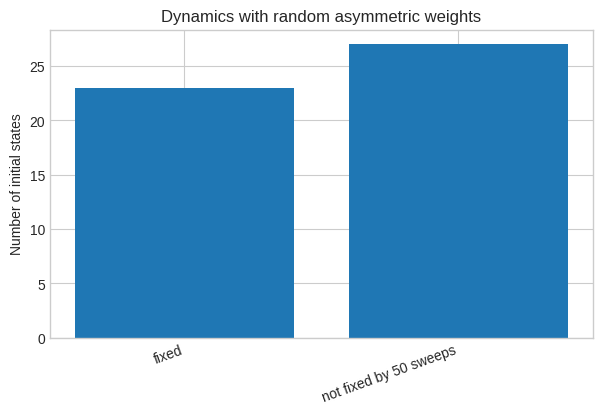

{'fixed': 23, 'not fixed by 50 sweeps': 27}
Tracked non-fixed run: status=max_sweeps, saved states=349, effective state count M=334.1


In [27]:
rng = np.random.default_rng(2)
N = 30
weights = b2_random_asymmetric_weights(N=N, rng=rng)
threshold = -weights.sum(axis=1)  # 0/1, U=0 → -1/+1 equivalent threshold

statuses = []
tracked_run = None
for _ in range(50):
    initial_state = c2_random_state(N=N, rng=rng)
    run = d1_run_async(
        weights,
        initial_state,
        rng,
        max_sweeps=50,
        threshold=threshold,
        record_states=tracked_run is None,
    )
    statuses.append(run.status)
    if tracked_run is None and run.status != "fixed":
        tracked_run = run

display_statuses = [
    "fixed" if status == "fixed" else "not fixed by 50 sweeps"
    for status in statuses
]
labels, counts = np.unique(display_statuses, return_counts=True)
f2_plot_bar(
    labels,x
    counts,
    ylabel="Number of initial states",
    title="Dynamics with random asymmetric weights",
)
print(dict(zip(labels.tolist(), counts.tolist())))

if tracked_run is None:
    print("All 50 trials reached fixed points.")
else:
    effective_states = e3_effective_state_count(tracked_run.state_history)
    print(
        f"Tracked non-fixed run: status={tracked_run.status}, "
        f"saved states={len(tracked_run.state_history)}, "
        f"effective state count M={effective_states:.1f}"
    )


**对照论文**：论文报告最常见行为是稳定点，也偶见二周期与局部混沌游走；$N=30$ 的一次局部游走得到有效状态数 $M=25$。这里的数值会随随机矩阵和观测时长变化，重点是复现行为类型，而不是强求同一个 $M$。


## 4. 实验2：存储容量与信噪比

**原文定位**：论文 pp.2556–2557，图2；原文从 “Computer modeling” 开始描述容量模拟。

**问题**：当 $N=100$ 时，随着存储记忆数 $n$ 增加，正确召回如何下降？

**配方**：`a1 → b1 → c1 → d1 → e1 → f1`

每次试验都重新生成记忆和权重，运行后只保留终态误差；不会累计状态轨迹。


In [ ]:
rng = np.random.default_rng(102)
N = 100
n_values = np.arange(1, 21)
trials_per_n = 50
mean_errors = []
exact_rates = []
theory_exact_rates = []

for n in n_values:
    errors = []
    for _ in range(trials_per_n):
        memories = a1_make_random_memories(n=n, N=N, rng=rng)
        weights = b1_hebb_weights(memories)
        target_index = int(rng.integers(n))
        initial_state = c1_start_from_memory(memories, target_index)
        run = d1_run_async(weights, initial_state, rng)
        errors.append(e1_hamming_distance(run.final_state, memories[target_index]))

    errors = np.asarray(errors)
    mean_errors.append(float(errors.mean()))
    exact_rates.append(float(np.mean(errors == 0)))
    bit_error = theoretical_bit_error_probability(n=n, N=N)
    theory_exact_rates.append((1 - bit_error) ** N)

f1_plot_curve(
    n_values,
    {
        "Simulation: exact recall": exact_rates,
        "Gaussian approximation": theory_exact_rates,
    },
    xlabel="Number of stored memories n",
    ylabel="Exact recall probability",
    title="Hopfield storage capacity",
)
print("n=5,10,15 的平均错误位数：", {
    n: round(mean_errors[n - 1], 2) for n in (5, 10, 15)
})


**对照论文**：论文报告 $n=5$ 时记忆几乎总是稳定；在 $n=15\approx0.15N$ 时，约一半记忆仍接近原记忆，另一半严重失真。有限试验次数和随机种子会造成曲线波动。


## 5. 实验3：随机初态的吸引子分布

**原文定位**：论文 p.2557，“Given some arbitrary starting state …” 段落。

**问题**：随机初态最终落入指定记忆、记忆附近，还是伪吸引子？

**配方**：`a1 → b1 → c2 → d1 → e2 → f2`


In [ ]:
rng = np.random.default_rng(103)
N, n, trials = 30, 5, 200
memories = a1_make_random_memories(n=n, N=N, rng=rng)
weights = b1_hebb_weights(memories)
nominal_attractors = np.vstack([memories, -memories])
outcomes = {"assigned memory": 0, "near memory": 0, "spurious": 0}

for _ in range(trials):
    initial_state = c2_random_state(N=N, rng=rng)
    run = d1_run_async(weights, initial_state, rng)
    _, distance = e2_identify_attractor(run.final_state, nominal_attractors)
    if distance == 0:
        outcomes["assigned memory"] += 1
    elif distance <= 2:
        outcomes["near memory"] += 1
    else:
        outcomes["spurious"] += 1

f2_plot_bar(
    list(outcomes),
    [100 * value / trials for value in outcomes.values()],
    ylabel="Share of trials (%)",
    title="Attractors reached from random initial states",
)
print(outcomes)


**对照论文**：论文一次统计约为 85% 指定记忆、10% 无明显意义的稳定态、5% 记忆附近状态。这里使用“距名义吸引子不超过 2 bit”作为“附近”的可执行定义。


## 6. 实验4：吸引盆与纠错能力

**原文定位**：论文 p.2557，“partially random starting states” 段落。

**问题**：从已存记忆翻转多少 bit 后，网络仍能回到最近的原记忆？

**配方**：`a1 → b1 → c3 → d1 → e2 → f1`


In [ ]:
rng = np.random.default_rng(104)
N, n = 30, 5
distances = np.arange(0, 13)
trials_per_distance = 100
memories = a1_make_random_memories(n=n, N=N, rng=rng)
weights = b1_hebb_weights(memories)
recall_rates = []

for distance in distances:
    successes = 0
    for _ in range(trials_per_distance):
        target_index = int(rng.integers(n))
        initial_state = c3_perturb_memory(
            memories[target_index],
            n_flips=int(distance),
            rng=rng,
        )
        run = d1_run_async(weights, initial_state, rng)
        nearest_index, _ = e2_identify_attractor(run.final_state, memories)
        successes += int(nearest_index == target_index)
    recall_rates.append(successes / trials_per_distance)

f1_plot_curve(
    distances,
    {"Return to target memory": recall_rates},
    xlabel="Initial Hamming distance from target",
    ylabel="Recall probability",
    title="Basin size and error correction",
)


**对照论文**：论文报告距离不超过 5 bit 时返回最近记忆的概率超过 90%，距离 12 时下降到约 0.2。随机记忆集合不同会明显改变单次曲线。


## 7. 实验5：截断权重

**原文定位**：论文 p.2557，“clipped $T_{ij}$” 段落。

**问题**：把 Hebb 权重压成 $\{-1,0,+1\}$ 后，容量和误差怎样变化？

**配方**：`a1 → b1+b3 → c1 → d1 → e1 → f2`


In [ ]:
rng = np.random.default_rng(105)
N, trials = 100, 100
conditions = [
    ("standard n=12", 12, False),
    ("clipped n=9", 9, True),
    ("clipped n=13", 13, True),
]
condition_errors = []

for _, n, clipped in conditions:
    errors = []
    for _ in range(trials):
        memories = a1_make_random_memories(n=n, N=N, rng=rng)
        weights = b1_hebb_weights(memories)
        if clipped:
            weights = b3_clip_weights(weights)
        target_index = int(rng.integers(n))
        initial_state = c1_start_from_memory(memories, target_index)
        run = d1_run_async(weights, initial_state, rng)
        errors.append(e1_hamming_distance(run.final_state, memories[target_index]))
    condition_errors.append(float(np.mean(errors)))

f2_plot_bar(
    [name for name, _, _ in conditions],
    condition_errors,
    ylabel="Mean bit errors",
    title="Standard versus clipped weights",
)


**对照论文**：论文报告 $N=100$ 时，截断权重的 $n=9$ 与普通权重的 $n=12$ 错误水平相近；截断权重的最大 Shannon 信息量约出现在 $n=13$。


## 8. 机制扩展1：有限权重与自然遗忘

**原文定位**：论文 p.2557，“The saturation of the possible size” 段落。

**问题**：权重限制在 $0,\pm1,\pm2,\pm3$ 时，新记忆是否逐渐覆盖旧记忆？

**配方**：`a1 → b5 → c1 → d1 → e1 → f1`


In [ ]:
rng = np.random.default_rng(106)
N, stream_length = 100, 80
memory_stream = a1_make_random_memories(n=stream_length, N=N, rng=rng)
weights = np.zeros((N, N), dtype=float)

for memory in memory_stream:
    weights = b5_add_memory_with_saturation(weights, memory, limit=3)

ages = np.arange(stream_length - 1, -1, -1)
errors_by_age = []
for memory in memory_stream:
    initial_state = c1_start_from_memory(memory[None, :], 0)
    run = d1_run_async(weights, initial_state, rng)
    errors_by_age.append(e1_hamming_distance(run.final_state, memory))

order = np.argsort(ages)
f1_plot_curve(
    ages[order],
    {"Recall error": np.asarray(errors_by_age)[order]},
    xlabel="Memory age (0 = newest)",
    ylabel="Bit errors",
    title="Natural forgetting with bounded weights",
)


**解释**：这是论文给出的硬件机制演示，不是带完整统计表的独立实验。曲线应总体表现为旧记忆更容易失真，但单条随机记忆会有波动。


## 9. 实验6：单向连接与软失效

**原文定位**：论文 p.2557，“Simulations were carried out with only one ij connection” 段落。

**问题**：若每对神经元只保留一个连接方向，稳定记忆是否仍存在？

**配方**：`a1 → b1+b4 → c1 → d1 → e1 → f2`


In [ ]:
rng = np.random.default_rng(107)
N, n, trials = 100, 10, 100
errors = {"symmetric": [], "one direction per pair": []}

for _ in range(trials):
    memories = a1_make_random_memories(n=n, N=N, rng=rng)
    symmetric = b1_hebb_weights(memories)
    one_way = b4_keep_one_direction(symmetric, rng)
    target_index = int(rng.integers(n))
    initial_state = c1_start_from_memory(memories, target_index)

    for label, weights in [
        ("symmetric", symmetric),
        ("one direction per pair", one_way),
    ]:
        run = d1_run_async(weights, initial_state, rng)
        errors[label].append(
            e1_hamming_distance(run.final_state, memories[target_index])
        )

f2_plot_bar(
    list(errors),
    [float(np.mean(values)) for values in errors.values()],
    ylabel="Mean bit errors",
    title="Soft failure after removing one connection direction",
)


**对照论文**：论文观察到错误率提高，但算法仍产生稳定极小值；信噪比按约 $1/\sqrt{2}$ 降低，而不是突然完全失效。


## 10. 实验7：相似记忆的混淆与融合

**原文定位**：论文 p.2557，$N=100,n=8$，令第八条记忆与另一条的汉明距离为 30、20 或 10。

**问题**：两条记忆太相似时，它们保持分离、发生偏移，还是融合成同一吸引子？

**配方**：`a2 → b1 → c1 → d1 → e1/e2 → f1`


In [ ]:
rng = np.random.default_rng(108)
N, n, trials = 100, 8, 60
distances = [30, 20, 10]
fused_rates = []
displaced_errors = []

for distance in distances:
    fused = 0
    total_error = 0
    for _ in range(trials):
        memories = a2_make_close_memories(
            n=n,
            N=N,
            distance=distance,
            rng=rng,
        )
        weights = b1_hebb_weights(memories)
        run_a = d1_run_async(
            weights,
            c1_start_from_memory(memories, 0),
            rng,
        )
        run_b = d1_run_async(
            weights,
            c1_start_from_memory(memories, n - 1),
            rng,
        )
        fused += int(np.array_equal(run_a.final_state, run_b.final_state))
        total_error += (
            e1_hamming_distance(run_a.final_state, memories[0])
            + e1_hamming_distance(run_b.final_state, memories[-1])
        ) / 2
    fused_rates.append(fused / trials)
    displaced_errors.append(total_error / trials)

f1_plot_curve(
    distances,
    {
        "Fusion rate": fused_rates,
        "Mean displacement / 100": np.asarray(displaced_errors) / 100,
    },
    xlabel="Hamming distance between the close pair",
    ylabel="Rate",
    title="Close memories: separation to fusion",
)


**对照论文**：距离 30 时通常都稳定；距离 20 时极小值通常仍分离但位置偏移；距离 10 时经常融合。


## 11. 机制扩展2：阈值与“不熟悉”状态

**原文定位**：论文 p.2557，讨论统一阈值如何让静默状态成为可能的稳定态。

**问题**：提高阈值后，与任何记忆都不像的输入是否更容易落入全静默状态？

**编码提醒**：论文 $\{0,1\}$ 编码中的 `0000…`，在这里的 $\{-1,+1\}$ 编码中对应全 `-1`。

**配方**：`a1 → b1 → c1/c4 → d1 → e2 → f1`


In [ ]:
rng = np.random.default_rng(109)
N, n, trials = 100, 5, 100
memories = a1_make_random_memories(n=n, N=N, rng=rng)
weights = b1_hebb_weights(memories)
silent_state = -np.ones(N, dtype=np.int8)
threshold_values = [0.0, 60.0, 70.0, 80.0]
unfamiliar_silent_rates = []
familiar_silent_rates = []

for threshold in threshold_values:
    unfamiliar_silent = 0
    familiar_silent = 0
    for _ in range(trials):
        unfamiliar_state = c4_unfamiliar_state(N=N, rng=rng)
        unfamiliar_run = d1_run_async(
            weights,
            unfamiliar_state,
            rng,
            threshold=threshold,
        )
        _, distance = e2_identify_attractor(
            unfamiliar_run.final_state,
            silent_state[None, :],
        )
        unfamiliar_silent += int(distance == 0)

        familiar_index = int(rng.integers(n))
        familiar_state = c1_start_from_memory(memories, familiar_index)
        familiar_run = d1_run_async(
            weights,
            familiar_state,
            rng,
            threshold=threshold,
        )
        _, distance = e2_identify_attractor(
            familiar_run.final_state,
            silent_state[None, :],
        )
        familiar_silent += int(distance == 0)

    unfamiliar_silent_rates.append(unfamiliar_silent / trials)
    familiar_silent_rates.append(familiar_silent / trials)

f1_plot_curve(
    threshold_values,
    {
        "Unfamiliar input": unfamiliar_silent_rates,
        "Familiar input": familiar_silent_rates,
    },
    xlabel="Uniform threshold",
    ylabel="Probability of the silent state",
    title="Threshold-based novelty recognition",
)


**解释**：这是阈值机制的可执行演示。阈值的数值依赖编码和权重是否归一化，不能直接把这里的数值与论文 $\{0,1\}$ 记号逐字等同。


## 12. 实验8：严重过载下的熟悉度识别

**原文定位**：论文 p.2558，$N=100,n=500$，过载约 25 倍。

**问题**：当所有记忆都不再是稳定点时，能否通过初始处理速率区分熟悉与陌生输入？

**配方**：`a1 → b1 → c1/c4 → e4 → f2`

这里不保存轨迹，只在线统计前 $N/2$ 次更新尝试中的翻转比例。


In [ ]:
rng = np.random.default_rng(110)
N, n, trials = 100, 500, 100
memories = a1_make_random_memories(n=n, N=N, rng=rng)
weights = b1_hebb_weights(memories)
familiar_rates = []
unfamiliar_rates = []

for _ in range(trials):
    familiar_index = int(rng.integers(n))
    familiar_state = c1_start_from_memory(memories, familiar_index)
    unfamiliar_state = c4_unfamiliar_state(N=N, rng=rng)
    familiar_rates.append(
        e4_initial_flip_rate(
            weights,
            familiar_state,
            rng,
            attempts=N // 2,
        )
    )
    unfamiliar_rates.append(
        e4_initial_flip_rate(
            weights,
            unfamiliar_state,
            rng,
            attempts=N // 2,
        )
    )

f2_plot_bar(
    ["Familiar input", "Unfamiliar input"],
    [float(np.mean(familiar_rates)), float(np.mean(unfamiliar_rates))],
    ylabel="Flip rate during initial updates",
    title="Familiarity signal under severe overload",
)
print(
    f"熟悉={np.mean(familiar_rates):.3f}, "
    f"陌生={np.mean(unfamiliar_rates):.3f}"
)


**对照论文**：论文报告陌生状态的初始处理速率通常更快，因此即使不能召回具体记忆，网络仍保留熟悉度信号。


## 13. 机制扩展3：相关记忆与部分信息补全

**原文定位**：论文 p.2558，式 (11)–(12)。

**问题**：若记忆共享统计相关性，部分输入是否会被补全为符合共同结构的状态？

**配方**：`a3 → b1 → c3 → d1 → e1 → f2`


In [ ]:
rng = np.random.default_rng(111)
N, n, trials = 100, 30, 100
memories, prototype = a3_make_correlated_memories(
    n=n,
    N=N,
    flip_probability=0.2,
    rng=rng,
)
weights = b1_hebb_weights(memories)
before = []
after = []

for _ in range(trials):
    target_index = int(rng.integers(n))
    initial_state = c3_perturb_memory(
        memories[target_index],
        n_flips=30,
        rng=rng,
    )
    before.append(e1_hamming_distance(initial_state, prototype))
    run = d1_run_async(weights, initial_state, rng)
    after.append(e1_hamming_distance(run.final_state, prototype))

f2_plot_bar(
    ["Before completion", "After completion"],
    [float(np.mean(before)), float(np.mean(after))],
    ylabel="Mean Hamming distance from prototype",
    title="Completion from correlated structure",
)


**解释**：论文这里给出的是相关矩阵下的机制推演，不是完整统计实验。本节用共同原型构造相关性，展示同一思想；它不是式 (11)–(12) 的逐项精确复刻。


## 14. 实验9：时间序列记忆

**原文定位**：论文 p.2558，式 (13)，紧邻 *Discussion* 之前。

**问题**：向 Hebb 权重加入从当前记忆指向下一记忆的非对称项，能否让状态按顺序跳转？

**配方**：`a1 → b1+b6 → c1 → d1 → e5 → f2`


In [ ]:
rng = np.random.default_rng(112)
N, n = 100, 4
memories = a1_make_random_memories(n=n, N=N, rng=rng)
base_weights = b1_hebb_weights(memories)
strengths = [0.2, 0.5, 1.0]
path_lengths = []

for strength in strengths:
    weights = b6_add_sequence_terms(
        base_weights,
        memories,
        strength=strength,
    )
    initial_state = c1_start_from_memory(memories, 0)
    run = d1_run_async(
        weights,
        initial_state,
        rng,
        max_sweeps=20,
        record_states=True,
    )
    path = e5_nearest_memory_path(run.state_history, memories)
    path_lengths.append(len(path))
    print(f"A={strength}: 最近记忆路径 {path}, status={run.status}")

f2_plot_bar(
    [str(value) for value in strengths],
    path_lengths,
    ylabel="Number of consecutive memory regions visited",
    title="Strength of the asymmetric sequence term",
)


**对照论文**：论文观察到适当强度可使系统在 $V^s$ 附近停留后移向 $V^{s+1}$，但超过四个状态的序列难以生成，即使短序列也不完全可靠。


## 15. 总结：如何读这份 notebook

每个实验都保留四个层次：

1. **原文定位**：论文页码与所在段落；
2. **实验问题**：这一组计算究竟验证什么；
3. **组件配方**：从 `a/b/c/d/e/f` 中选择了哪些机制；
4. **结果对照**：说明复现结果与论文观察是否同方向，以及哪里不是严格复刻。

### 结果解释边界

- 所有随机实验都固定 seed，便于重新运行，但单次小样本不等于论文原始统计。
- `record_states=False`、`record_energy=False` 是密集扫描的默认值。
- 非对称权重没有严格单调能量函数，不能套用对称网络的收敛证明。
- 论文的 $\{0,1\}$ 与代码的 $\{-1,+1\}$ 等价，但阈值数值必须经过编码变换后解释。
- “机制扩展”章节是可执行解释，不冒充论文已经完整报告的独立实验。
